In [1]:
import numpy as np # para manipular arrays y realizar operaciones matematicas
import pandas as pd # para manipular dataframes y realizar operaciones de limpieza y analisis de datos
import matplotlib.pyplot as plt # para crear graficos y visualizaciones de datos
import seaborn as sns # para crear graficos y visualizaciones de datos mas avanzados y atractivos
import scipy as sp # general de scipy, aunque lo usaremos principalmente para estadistica
import scipy.stats as stats # para realizar pruebas de hipotesis y analisis estadistico
import pingouin as pg # para realizar pruebas de hipotesis y analisis estadistico de manera mas facil y rapida
import statsmodels.api as sm # para realizar pruebas de hipotesis y analisis estadistico de manera mas avanzada

# Test de Hipótesis para Dos Muestras

Es posible generar test de hipótesis sobre dos poblaciones basados en el la diferencia entre los estimadores de las mismas. De esta forma, el test de hipótesis para dos muestras es, en principio, equivalente a los test de hipótesis para 1 muestra, pero considerando ahora la diferencia entre las mismas.

## Z-test para dos muestras: Test sobre las medias con varianza conocida.

Considerando el caso en que dos muestras que cumplen con los siguientes supuestos:
1. Muestra $\mathbf{X}_1$ es una muestra aleatoria de la población 1.
2. Muestra $\mathbf{X}_2$ es una muestra aleatoria de la población 2.
3. Las poblaciones $\mathbf{X}_1$ y $\mathbf{X}_2$ son independientes.
4. Ambas poblaciones son independientes.

En este caso, la cantidad
$$
Z = \frac{\overline{X}_1 - \overline{X}_2 - (\mu_1 - \mu_2)}{\sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}}
$$

Sigue una distribución $\mathcal{N}(0,1)$.

> NOTA: Notemos que es la misma noción derivada de los intervalos de confianza.

En base a es posible plantear el siguiente test de hipótesis:
$$ 
H_0: \mu_1 - \mu_2 = \Delta_0 \; H_a: \mu_1 - \mu_2 \neq \Delta_0  
$$ 
Donde ahora trabajamos sobre la diferncia de las medias. Así, obtenemos nuestro test-Z para dos muestras. Debido que, al igual que para el estadístico Z_0, podemos definir:
$$
Z_0 = \frac{\overline{X}_1 - \overline{X}_2 - \Delta_0}{\sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}}
$$

Donde la distribución de referencia es $\mathcal{N}(0,1)$. Por ende, tenemos los siguientes pares hipótesis alternativa-valor p.
- $H_a: \mu_1 - \mu_2 \neq \Delta_0$: $p-val = 2\cdot [1-\Phi(|z_0|)]$
- $H_a: \mu_1-\mu_2 > \Delta_0$: $p-val = 1-\Phi(z_0)$
- $H_a: \mu_1 - \mu_2 <\Delta_0$: $p-val = \Phi(z_0)$

> Aproximación de muestras grandes:
> Cuándo n>40, se puede aproximar $\sigma$ con $S$.

In [2]:
def ztest_2samp(dato1, dato2, pop_var1 = 1, pop_var2 = 1, alternative = 'two-sided'):
    '''
    Z-test para comparar dos poblaciones.
    Este test asume varianzas poblacionales conocidas, que las muestras son independientes
    y siguen una distribución normal.
    Se utiliza cuando n < 30 y se conoce la desviación estándar poblacional.
    Cuando n > 30, se puede usar la desviación estándar de la muestra como una aproximación de la desviación estándar poblacional.
    ---
    Parámetros:
        dato1 : array_like
            Primera muestra de datos.
        dato2 : array_like
            Segunda muestra de datos.
        pop_var1 : float, optional
            Varianza poblacional de la primera muestra. Por defecto es 1.
        pop_var2 : float, optional
            Varianza poblacional de la segunda muestra. Por defecto es 1.
        alternative : str, optional
            Tipo de test de hipótesis a realizar. Puede ser 'two-sided', 'larger' o 'smaller'.
            Por defecto es 'two-sided'.
    Retorna:
        z : float
            Valor del estadístico z.
        p_value : float
            Valor p del testats.
    ---
    Ejemplo de uso:
    > dato1 = [5, 7, 8, 6, 9]
    > dato2 = [4, 6, 7, 5, 8]
    > pop_var1 = 2
    > pop_var2 = 3
    > z, p_value = ztest_2samp(dato1, dato2, pop_var1, pop_var2, alternative='greater')
    '''
    mean1 = np.mean(dato1) # media muestra 1
    mean2 = np.mean(dato2) # media muestra 2

    n1 = len(dato1) # tamaño muestra 1
    n2 = len(dato2) # tamaño muestra 2


    z = (mean1 - mean2)/ np.sqrt(pop_var1/n1 + pop_var2/n2) # estadistico z

    # calculamos el valor p dependiendo del tipo de test de hipótesis
    if alternative == 'two-sided':
        p_value = 2 * (1 - stats.norm.cdf(np.abs(z)))
    elif alternative == 'larger':
        p_value = 1 - stats.norm.cdf(z)
    elif alternative == 'smaller':
        p_value = stats.norm.cdf(z)
    else:
        raise ValueError("El valor de 'alternative' debe ser 'two-sided', 'larger' o 'smaller'.")

    return z, p_value

# ejemplo
dist1 = np.random.normal(loc=5, scale=2, size=20) # muestra 1
dist2 = np.random.normal(loc=4, scale=3, size=20) # muestra 2
# debido a que sabemos que es normal seguimos 
z, p_value = ztest_2samp(dist1, dist2, 
                         pop_var1=4,  # viene de la desviación estándar de la distribución, que es 2, elevada al cuadrado
                         pop_var2=9,# viene de la desviación estándar de la distribución, que es 3, elevada al cuadrado
                         alternative='two-sided')
print(f'Estadístico z: {z:.3f}')
print(f'Valor p: {p_value:.3f}')

# con muestra grande, 
dist1_grande = np.random.normal(loc=5, scale=2, size=100) # muestra 1
dist2_grande = np.random.normal(loc=4, scale=3, size=100) # muestra 2
# debido a que sabemos que es normal seguimos 
z, p_value = ztest_2samp(dist1_grande, dist2_grande, 
                         pop_var1=np.var(dist1_grande, ddof=1),  # usamos la varianza muestral como aproximación de la varianza poblacional
                         pop_var2=np.var(dist2_grande, ddof=1), # usamos la varianza muestral como aproximación de la varianza poblacional
                         alternative='two-sided')

print(f'Estadístico z: {z:.3f}')
print(f'Valor p: {p_value:.3f}')

Estadístico z: 3.074
Valor p: 0.002
Estadístico z: 3.951
Valor p: 0.000


### Error de tipo II y tamaño de muestra (Z-test dos muestras)

Al igual que en una muestra, para una prueba Z de dos colas sobre $\Delta = \mu_1 - \mu_2$, el error tipo II depende de la diferencia real $\Delta$ y del error estándar conjunto.

Si la hipótesis es $H_0: \Delta = \Delta_0$, entonces:
$$
\beta = \Phi\left(z_{\alpha/2} - \frac{\Delta - \Delta_0}{\sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}}\right) - \Phi\left(-z_{\alpha/2} - \frac{\Delta - \Delta_0}{\sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}}\right)
$$

Para tamaños de muestra balanceados ($n_1=n_2=n$), una aproximación útil del tamaño de muestra necesario es:
$$
n = \frac{(z_{\alpha/2} + z_\beta)^2 (\sigma_1^2 + \sigma_2^2)}{(\Delta - \Delta_0)^2}
$$

donde $\beta$ es el error tipo II objetivo y $1-\beta$ es la potencia del test.

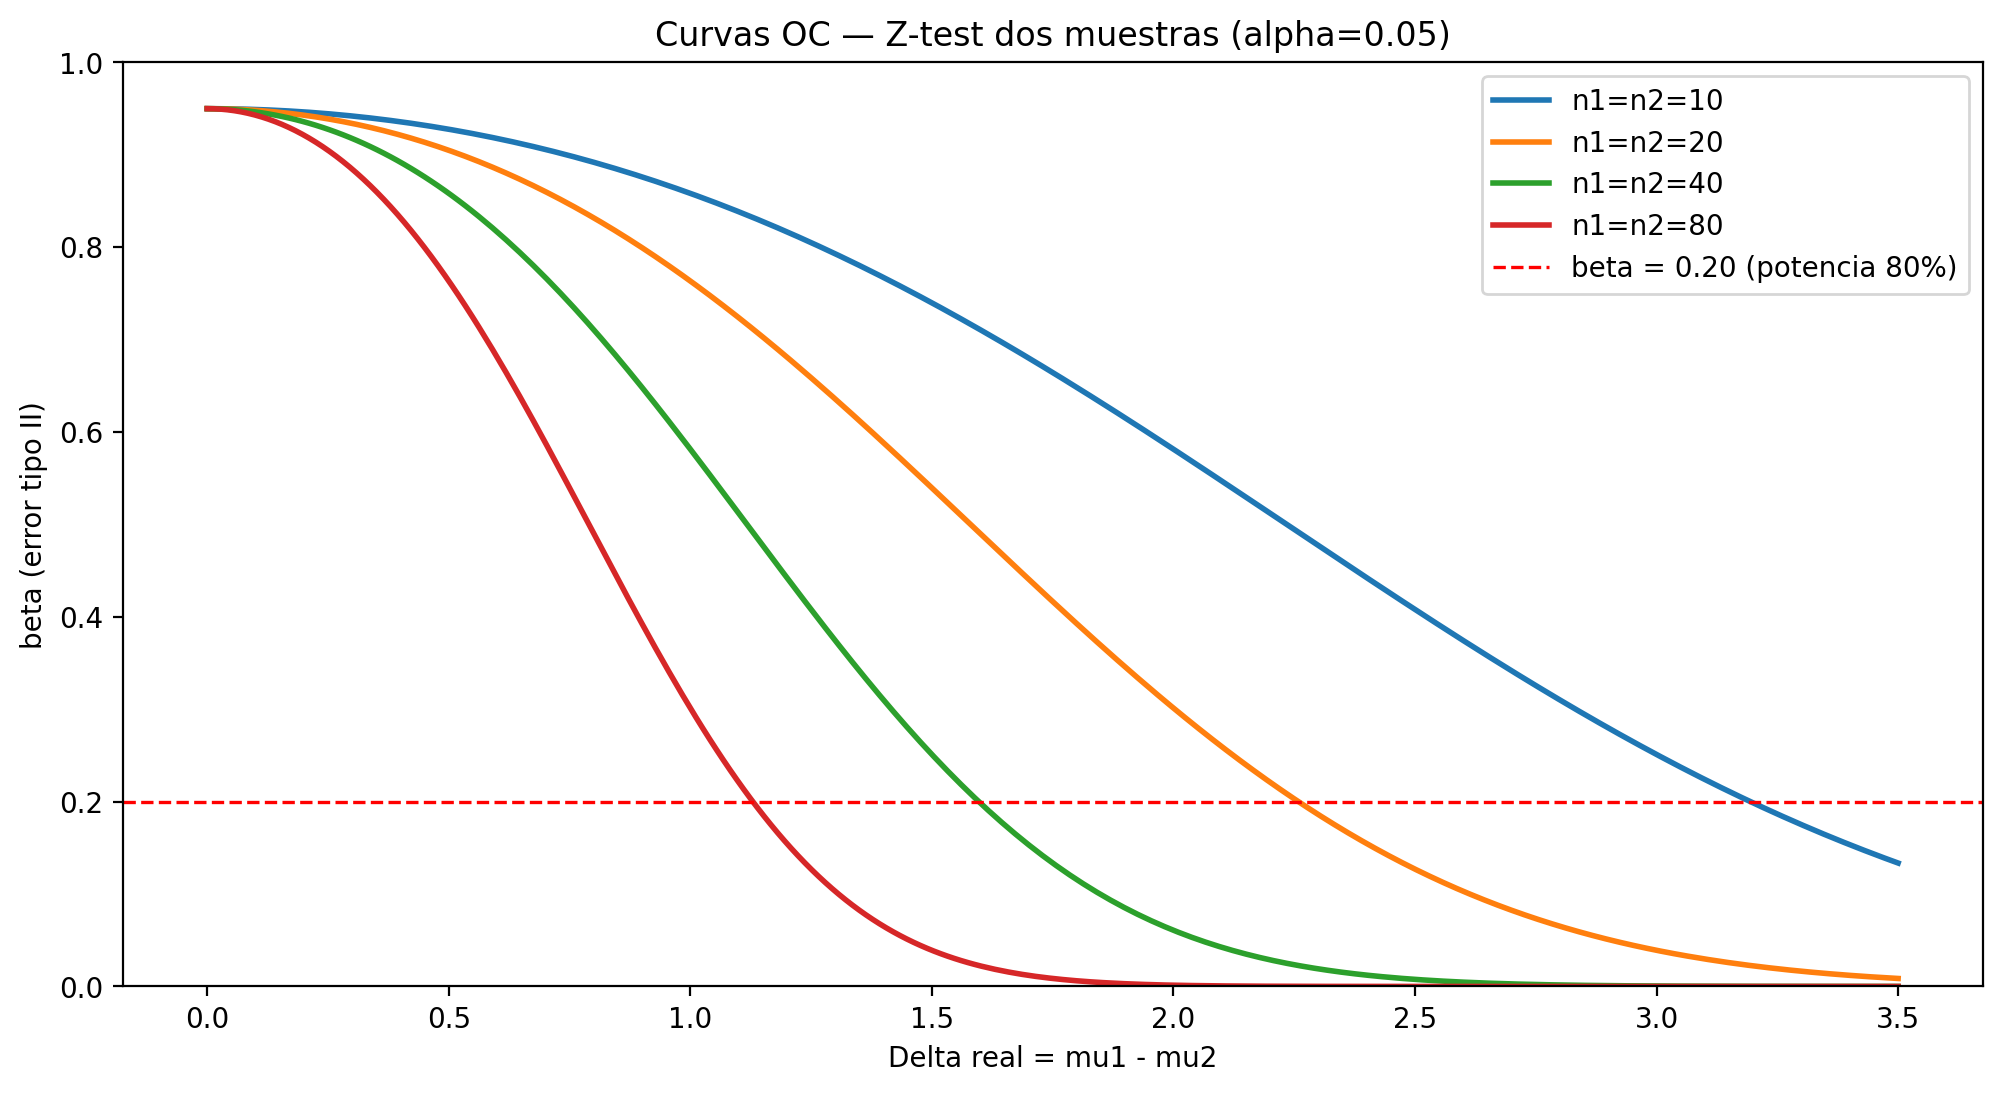

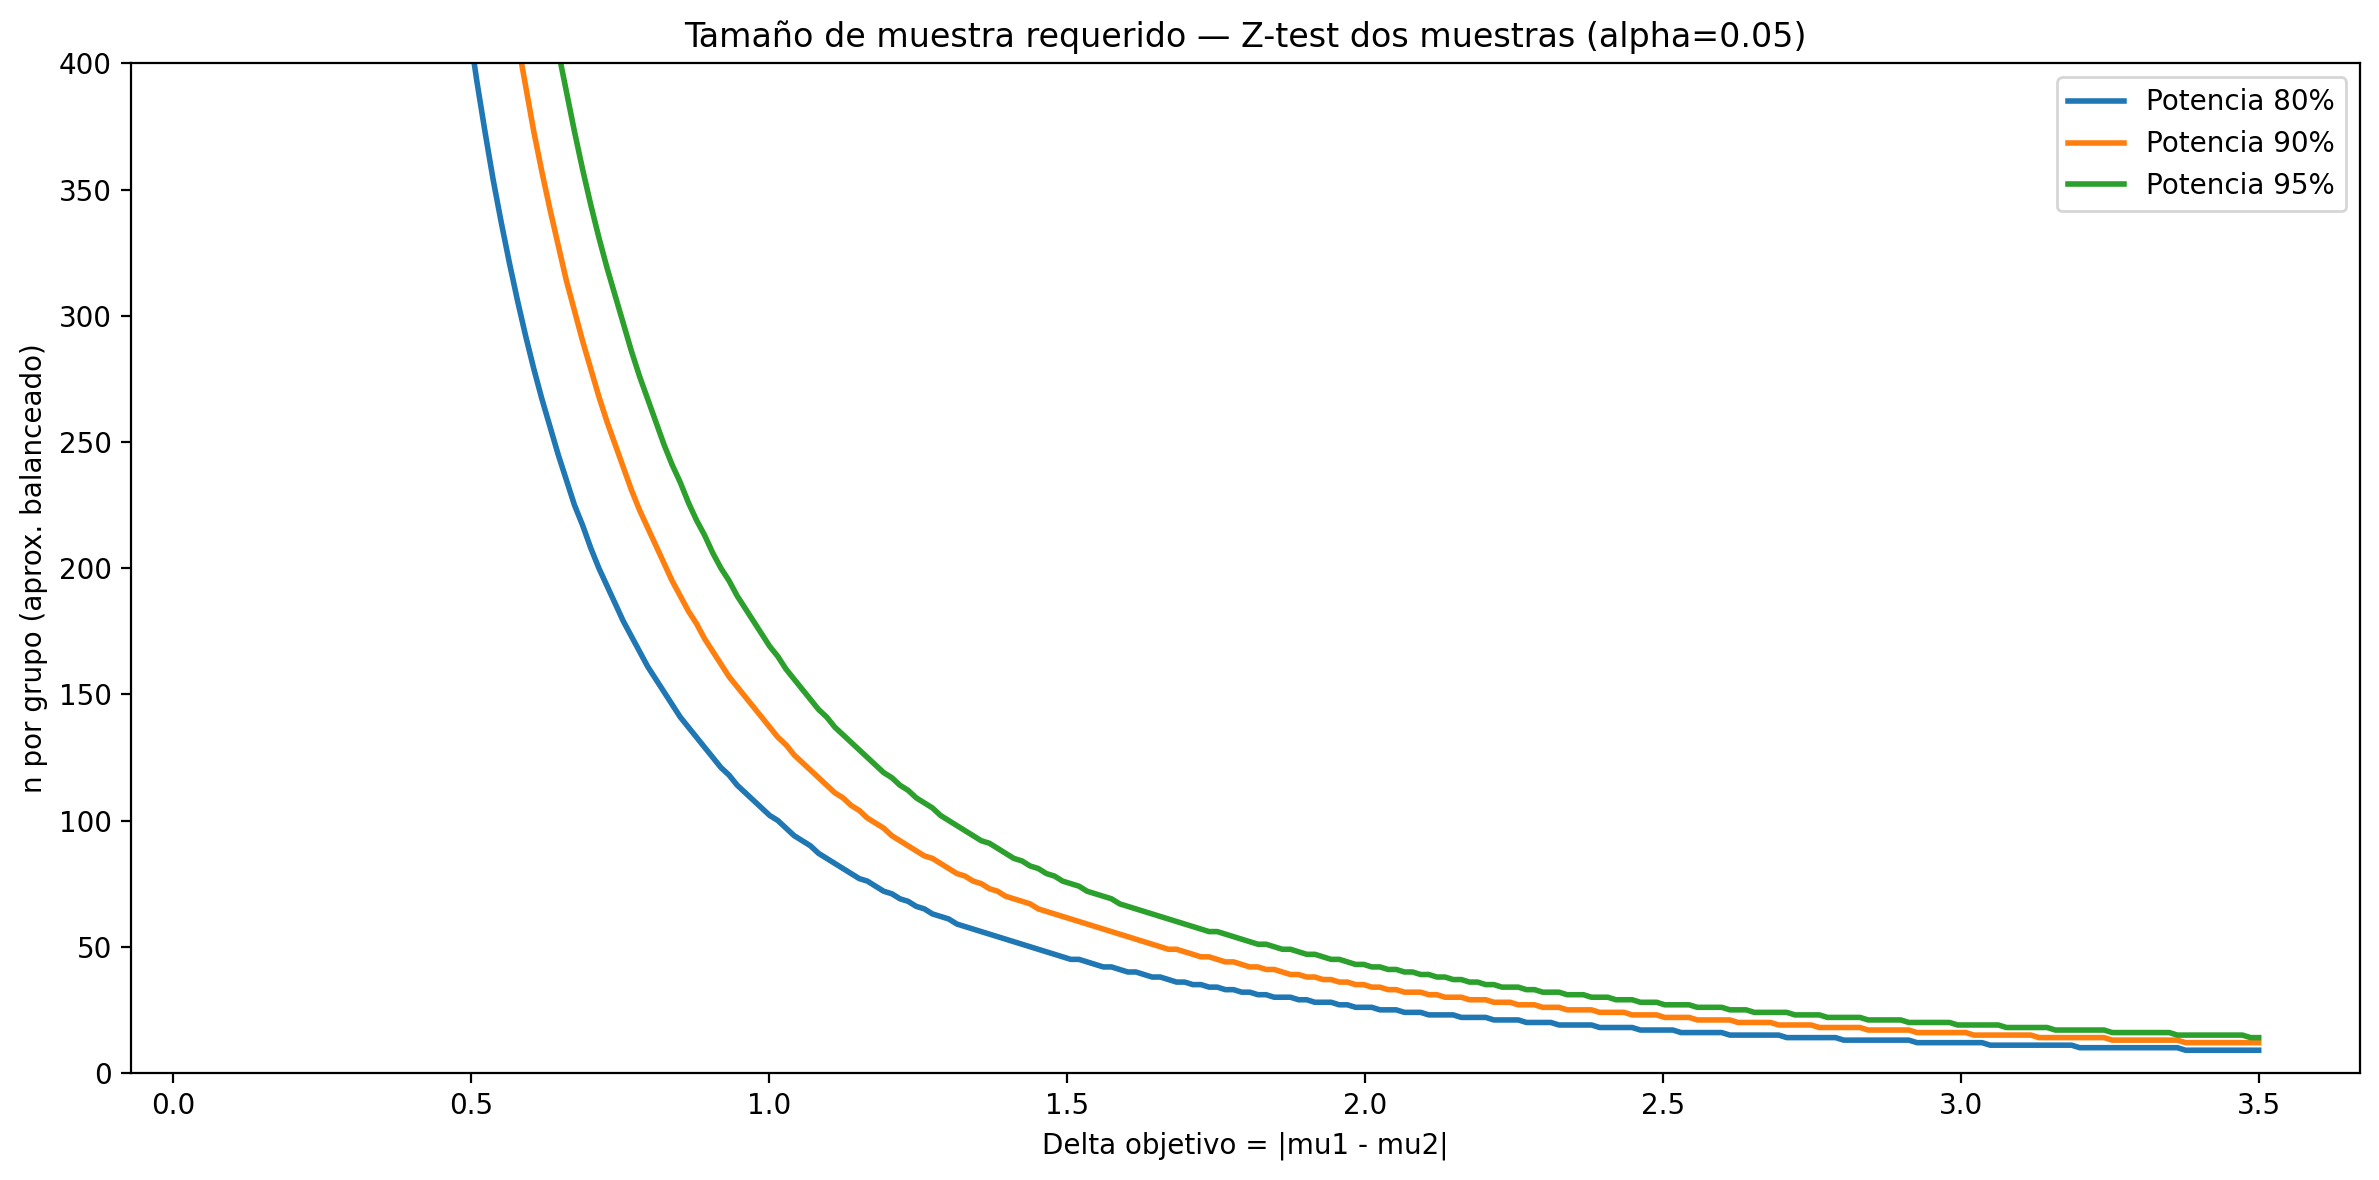

Para Delta real=1.2, n1=n2=25, alpha=0.05:
beta = 0.6162 -> potencia = 38.4%


In [3]:


def beta_ztest_2samp(delta_real, delta0, sigma1, sigma2, n1, n2, alpha=0.05):
    # Calcula el error tipo II (beta) para un Z-test de dos muestras.
    # es para una prueba de dos colas, por lo que se divide alpha entre 2
    z_a2 = stats.norm.ppf(1 - alpha/2)
    term = (delta_real - delta0) / np.sqrt((sigma1**2)/n1 + (sigma2**2)/n2)
    beta = stats.norm.cdf(z_a2 - term) - stats.norm.cdf(-z_a2 - term)
    return max(beta, 0)

# Potencia y tamaño de muestra para Z-test de dos muestras
alpha = 0.05
sigma1 = 2.0
sigma2 = 3.0
delta0 = 0.0

# Curvas OC: beta vs delta real
delta_grid = np.linspace(0, 3.5, 250)
n_vals = [10, 20, 40, 80]

fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
for n in n_vals:
    betas = [beta_ztest_2samp(d, delta0, sigma1, sigma2, n, n, alpha) for d in delta_grid]
    ax.plot(delta_grid, betas, linewidth=2, label=f'n1=n2={n}')

ax.axhline(0.20, color='red', linestyle='--', linewidth=1.2, label='beta = 0.20 (potencia 80%)')
ax.set_title(f'Curvas OC — Z-test dos muestras (alpha={alpha})')
ax.set_xlabel('Delta real = mu1 - mu2')
ax.set_ylabel('beta (error tipo II)')
ax.set_ylim(0, 1)
ax.legend()
plt.show()

# Tamaño de muestra requerido para distintas potencias
delta_grid_n = np.linspace(0.1, 3.5, 250)
potencias = [0.80, 0.90, 0.95]
z_a2 = stats.norm.ppf(1 - alpha/2)

fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
for potencia in potencias:
    beta_obj = 1 - potencia
    z_b = stats.norm.ppf(1 - beta_obj)
    n_req = np.ceil(((z_a2 + z_b)**2 * (sigma1**2 + sigma2**2)) / ((delta_grid_n - delta0)**2)).astype(int)
    ax.plot(delta_grid_n, n_req, linewidth=2, label=f'Potencia {int(potencia*100)}%')

ax.set_title(f'Tamaño de muestra requerido — Z-test dos muestras (alpha={alpha})')
ax.set_xlabel('Delta objetivo = |mu1 - mu2|')
ax.set_ylabel('n por grupo (aprox. balanceado)')
ax.set_ylim(0, 400)
ax.legend()
plt.tight_layout()
plt.show()

# Ejemplo numérico
delta_real = 1.2
n_ej = 25
beta_ej = beta_ztest_2samp(delta_real, delta0, sigma1, sigma2, n_ej, n_ej, alpha)
print(f'Para Delta real={delta_real}, n1=n2={n_ej}, alpha={alpha}:')
print(f'beta = {beta_ej:.4f} -> potencia = {1-beta_ej:.1%}')

## Intervalo de confianza para la diferencia de medias de dos muestras 

Los intervalos de confianza para la difernecia de medias, con varianza conocida, vienenn dados por la siguiente expresión.

Dado un nivel de confianza $100(1-\alpha)\%$ se tiene que el intervalo de confianza para $\mu_1 - \mu_2$ es:
$$
\overline{x}_1 - \overline{x}_2 - z_{\alpha/2}\sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}} \le \mu_1 - \mu_2 \le\overline{x}_1 - \overline{x}_2 + z_{\alpha/2}\sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}
$$
Donde $z_{\alpha/2}$ es el quantil $1-\alpha/2$ de una distribución $\mathcal{N}(0,1)$.

Luego, el tamaño de muestra para asegurar una confianza $100(1-\alpha)\%$ viene dado por:
$$
n =\left( \frac{z_{\alpha/2}}{E}\right)^2  (\sigma_1^2 + \sigma_2^2)
$$
Donde $E$ corresponde al error de aproximar $\mu_1 - \mu_2$ con $\overline{x}_1 - \overline{x}_2$.

También, los intervalos de superiores y inferiores vienen dados por:

Sup: $$ \mu_1 - \mu_2 \le \overline{x}_1 - \overline{x}_2 + z_\alpha \sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}$$
Inf: 
$$  \overline{x}_1 - \overline{x}_2 - z_\alpha \sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}\le\mu_1 - \mu_2 $$

Cobertura observada: 92.0% (23/25)
Delta real usado en la simulación: 0.80


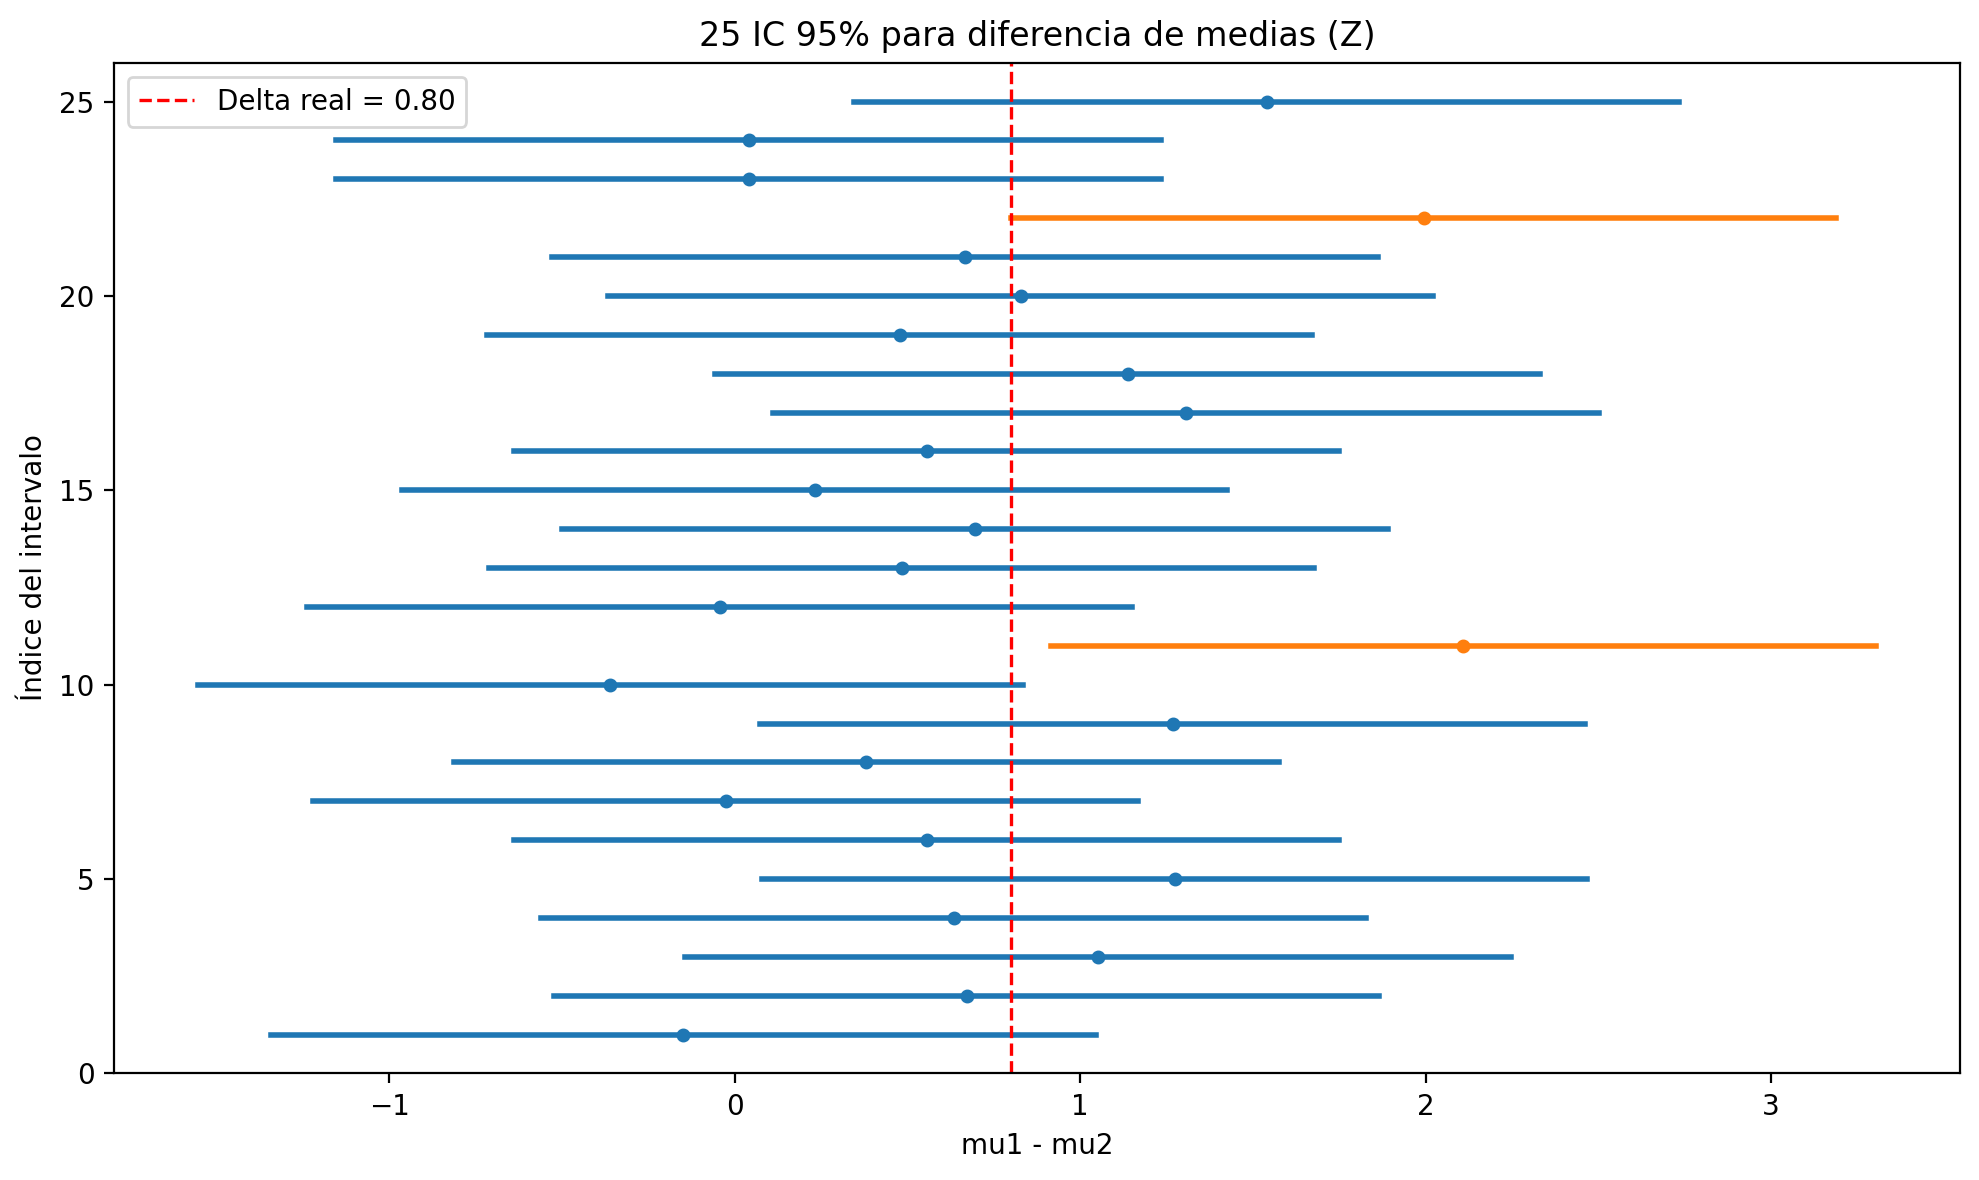

In [4]:
# Ejemplo: múltiples IC para mu1 - mu2 con varianzas conocidas (en horizontal)
np.random.seed(123)

# Parámetros conocidos
alpha = 0.05
sigma1 = 2.0
sigma2 = 3.0
n1 = 35
n2 = 35
n_intervalos = 25

# Diferencia real entre medias poblacionales
mu1_real = 10.0
mu2_real = 9.2
delta_real = mu1_real - mu2_real

z_crit = stats.norm.ppf(1 - alpha/2)
se = np.sqrt((sigma1**2)/n1 + (sigma2**2)/n2)

intervalos = []
for _ in range(n_intervalos):
    x1 = np.random.normal(loc=mu1_real, scale=sigma1, size=n1)
    x2 = np.random.normal(loc=mu2_real, scale=sigma2, size=n2)

    diff_mean = np.mean(x1) - np.mean(x2)
    ci_low = diff_mean - z_crit * se
    ci_high = diff_mean + z_crit * se
    cubre_delta = ci_low <= delta_real <= ci_high

    intervalos.append((diff_mean, ci_low, ci_high, cubre_delta))

cobertura = np.mean([it[3] for it in intervalos])
print(f'Cobertura observada: {cobertura:.1%} ({sum(it[3] for it in intervalos)}/{n_intervalos})')
print(f'Delta real usado en la simulación: {delta_real:.2f}')

# Gráfico horizontal de intervalos
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
for i, (mean_i, low_i, high_i, cubre_i) in enumerate(intervalos, start=1):
    color = 'tab:blue' if cubre_i else 'tab:orange'
    ax.plot([low_i, high_i], [i, i], color=color, linewidth=2)
    ax.plot(mean_i, i, 'o', color=color, markersize=4)

ax.axvline(delta_real, color='red', linestyle='--', linewidth=1.2, label=f'Delta real = {delta_real:.2f}')
ax.set_title(f'{n_intervalos} IC 95% para diferencia de medias (Z)')
ax.set_xlabel('mu1 - mu2')
ax.set_ylabel('Índice del intervalo')
ax.set_ylim(0, n_intervalos + 1)
ax.legend()
plt.tight_layout()
plt.show()

## Test-t para dos muestras: medias con varianza desconocida

Cuando no se conoce la varianza poblacional, usamos la distribución t como referencia. En dos muestras independientes, hay dos escenarios principales:

**Caso A: varianzas iguales ($\sigma_1^2 = \sigma_2^2$)**

Se usa el estimador agrupado:
$$
T_0 = \frac{\overline{X}_1 - \overline{X}_2 - \Delta_0}{S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}, \quad T_0 \sim t_{n_1+n_2-2}
$$
con
$$
S_p^2 = \frac{(n_1 - 1)S_1^2 + (n_2 - 1)S_2^2}{n_1 + n_2 - 2}
$$

**Caso B: varianzas distintas ($\sigma_1^2 \neq \sigma_2^2$)**

$$
T_0 = \frac{\overline{X}_1 - \overline{X}_2 - \Delta_0}{\sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}}
$$
con grados de libertad aproximados por
$$
\nu = \frac{\left( \frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1 - 1} + \frac{(s_2^2/n_2)^2}{n_2 - 1}}
$$

En la práctica, esta aproximación, denominada aproximación de Welch (en python `equal_var=False`) suele ser la opción por defecto más robusta cuando no hay evidencia fuerte de varianzas iguales.

El valor-p viene dado por:

- $H_a: \mu_1 - \mu_2 \neq \Delta_0$ (dos colas): $p$-valor $= 2\,[1 - F_{t, df}(|t_0|)]$
- $H_a: \mu_1 - \mu_2 > \Delta_0$ (cola derecha): $p$-valor $= 1 - F_{t,df}(t_0)$
- $H_a: \mu_1 - \mu_2 < \Delta_0$ (cola izquierda): $p$-valor $= F_{t,df}(t_0)$

Donde $df = n_1 + n_2 - 2$ en el caso de varianzas iguales, y $df = \nu$ cuando se hace la aproximación de Welch. 

En `scipy.stats.ttest_ind`, esto se controla con `alternative='two-sided'`, `'greater'` o `'less'`.

In [5]:
# Ejemplo t-test dos muestras independientes
np.random.seed(42)
datos1 = np.random.normal(loc=5, scale=2.0, size=30)
datos2 = np.random.normal(loc=4.3, scale=3.0, size=30)

# Verificación preliminar de igualdad de varianzas (Levene)
# Test de levene nos inidica si las varianzas de los dos grupos son iguales o no
# lo que nos ayuda a decidir si usar el t-test pooled (equal_var=True) o el t-test de Welch (equal_var=False)
lev_stat, lev_p = stats.levene(datos1, datos2, center='median')
print('Levene test (H0: varianzas iguales):')
print(f't={lev_stat:.3f}, p-value={lev_p:.3f}')

# t-test asumiendo varianzas iguales (pooled)
t_pooled, p_pooled = stats.ttest_ind(datos1, datos2, equal_var=True, alternative='two-sided')
print('\nT-test pooled (equal_var=True):')
print(f't={t_pooled:.3f}, p-value={p_pooled:.3f}')

# t-test de Welch (varianzas desiguales)
t_welch, p_welch = stats.ttest_ind(datos1, datos2, equal_var=False, alternative='two-sided')
print('\nT-test Welch (equal_var=False):')
print(f't={t_welch:.3f}, p-value={p_welch:.3f}')


Levene test (H0: varianzas iguales):
t=6.500, p-value=0.013

T-test pooled (equal_var=True):
t=1.133, p-value=0.262

T-test Welch (equal_var=False):
t=1.133, p-value=0.263


### Error de tipo II y potencia para t-test de dos muestras

Para comparar potencia entre diseños, se usa con frecuencia el tamaño de efecto de Cohen:
$$
d = \frac{|\mu_1 - \mu_2|}{s_p}
$$

Con dos grupos balanceados, la potencia aumenta cuando $d$ crece o cuando crece el tamaño muestral por grupo.

En Python, podemos calcular potencia y tamaño de muestra requerido con `statsmodels.stats.power.TTestIndPower`.

Potencia con d=0.5 y n=25 por grupo: 0.410
n por grupo para potencia 80%: 64


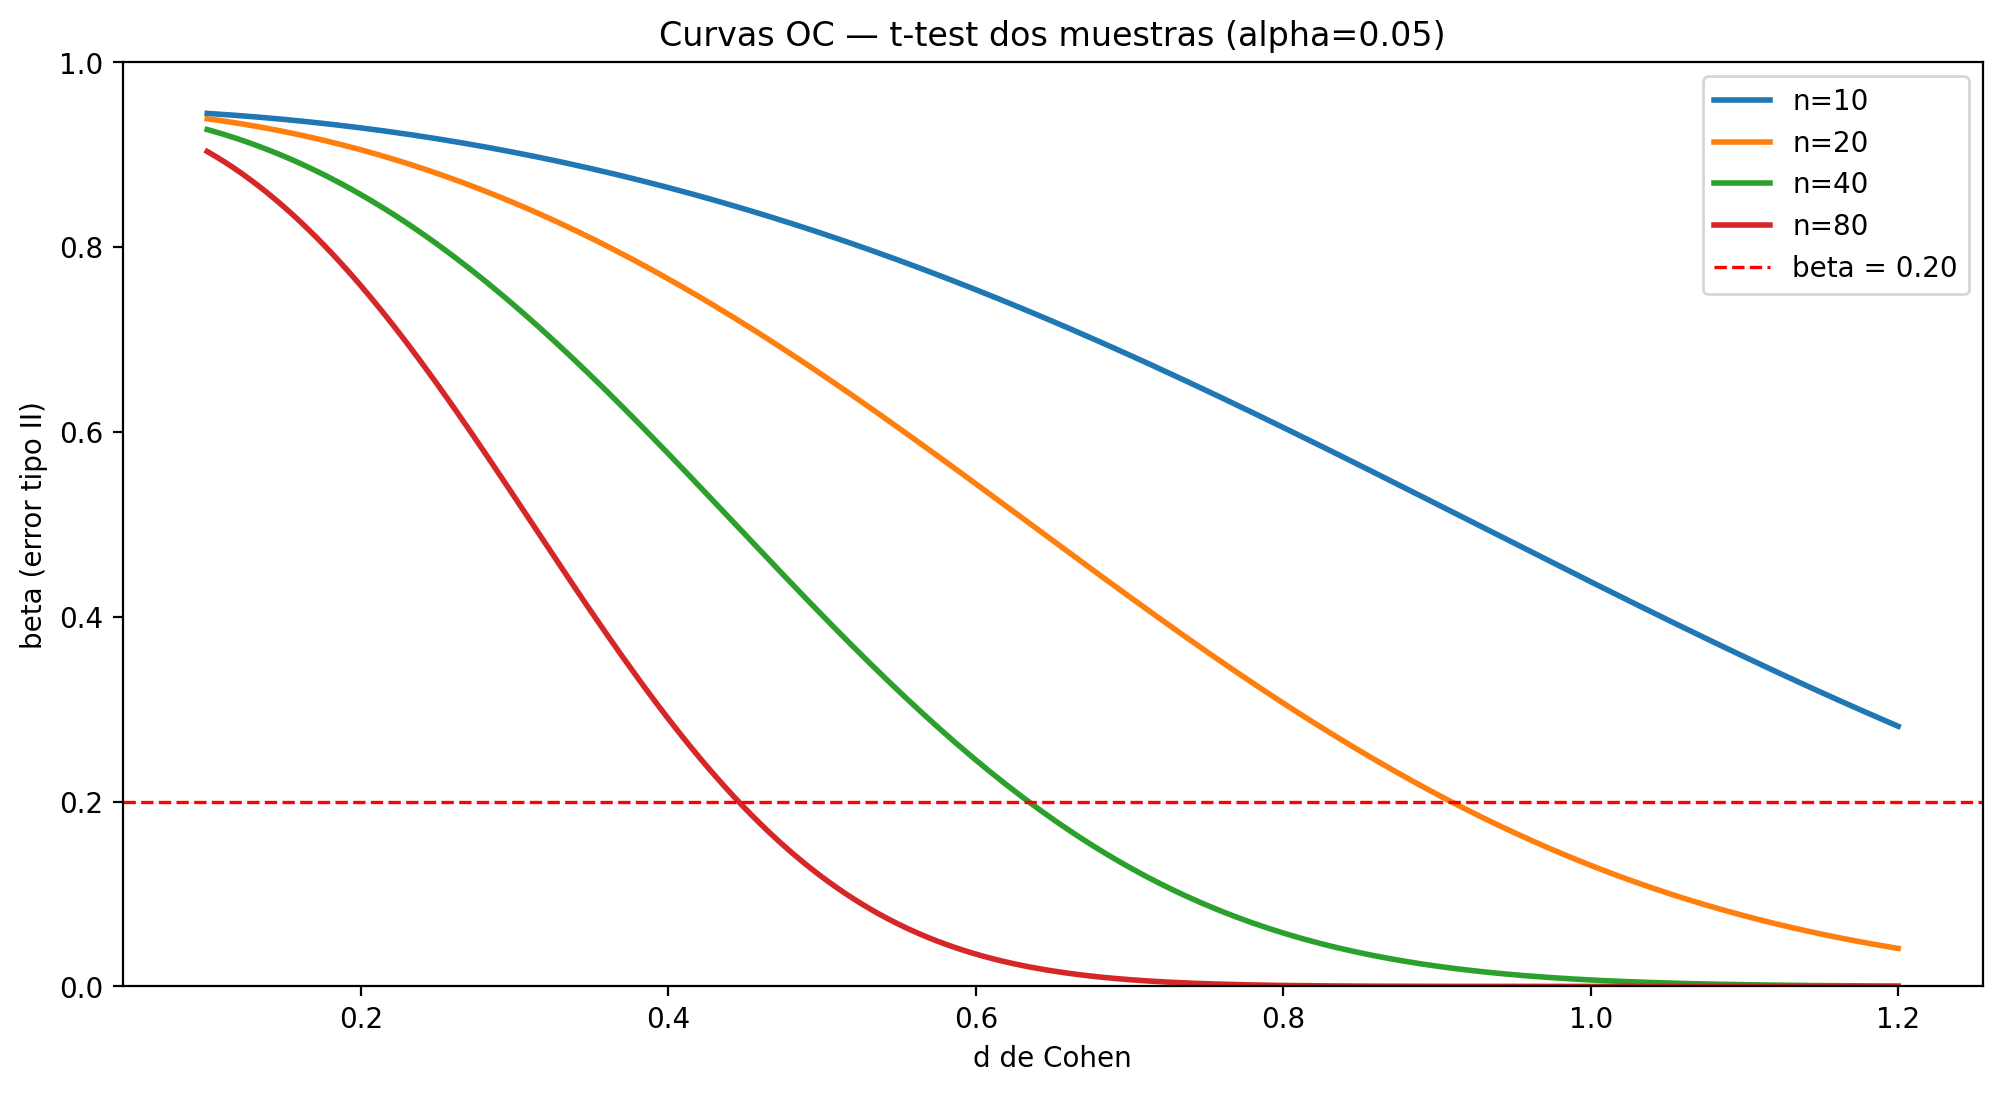

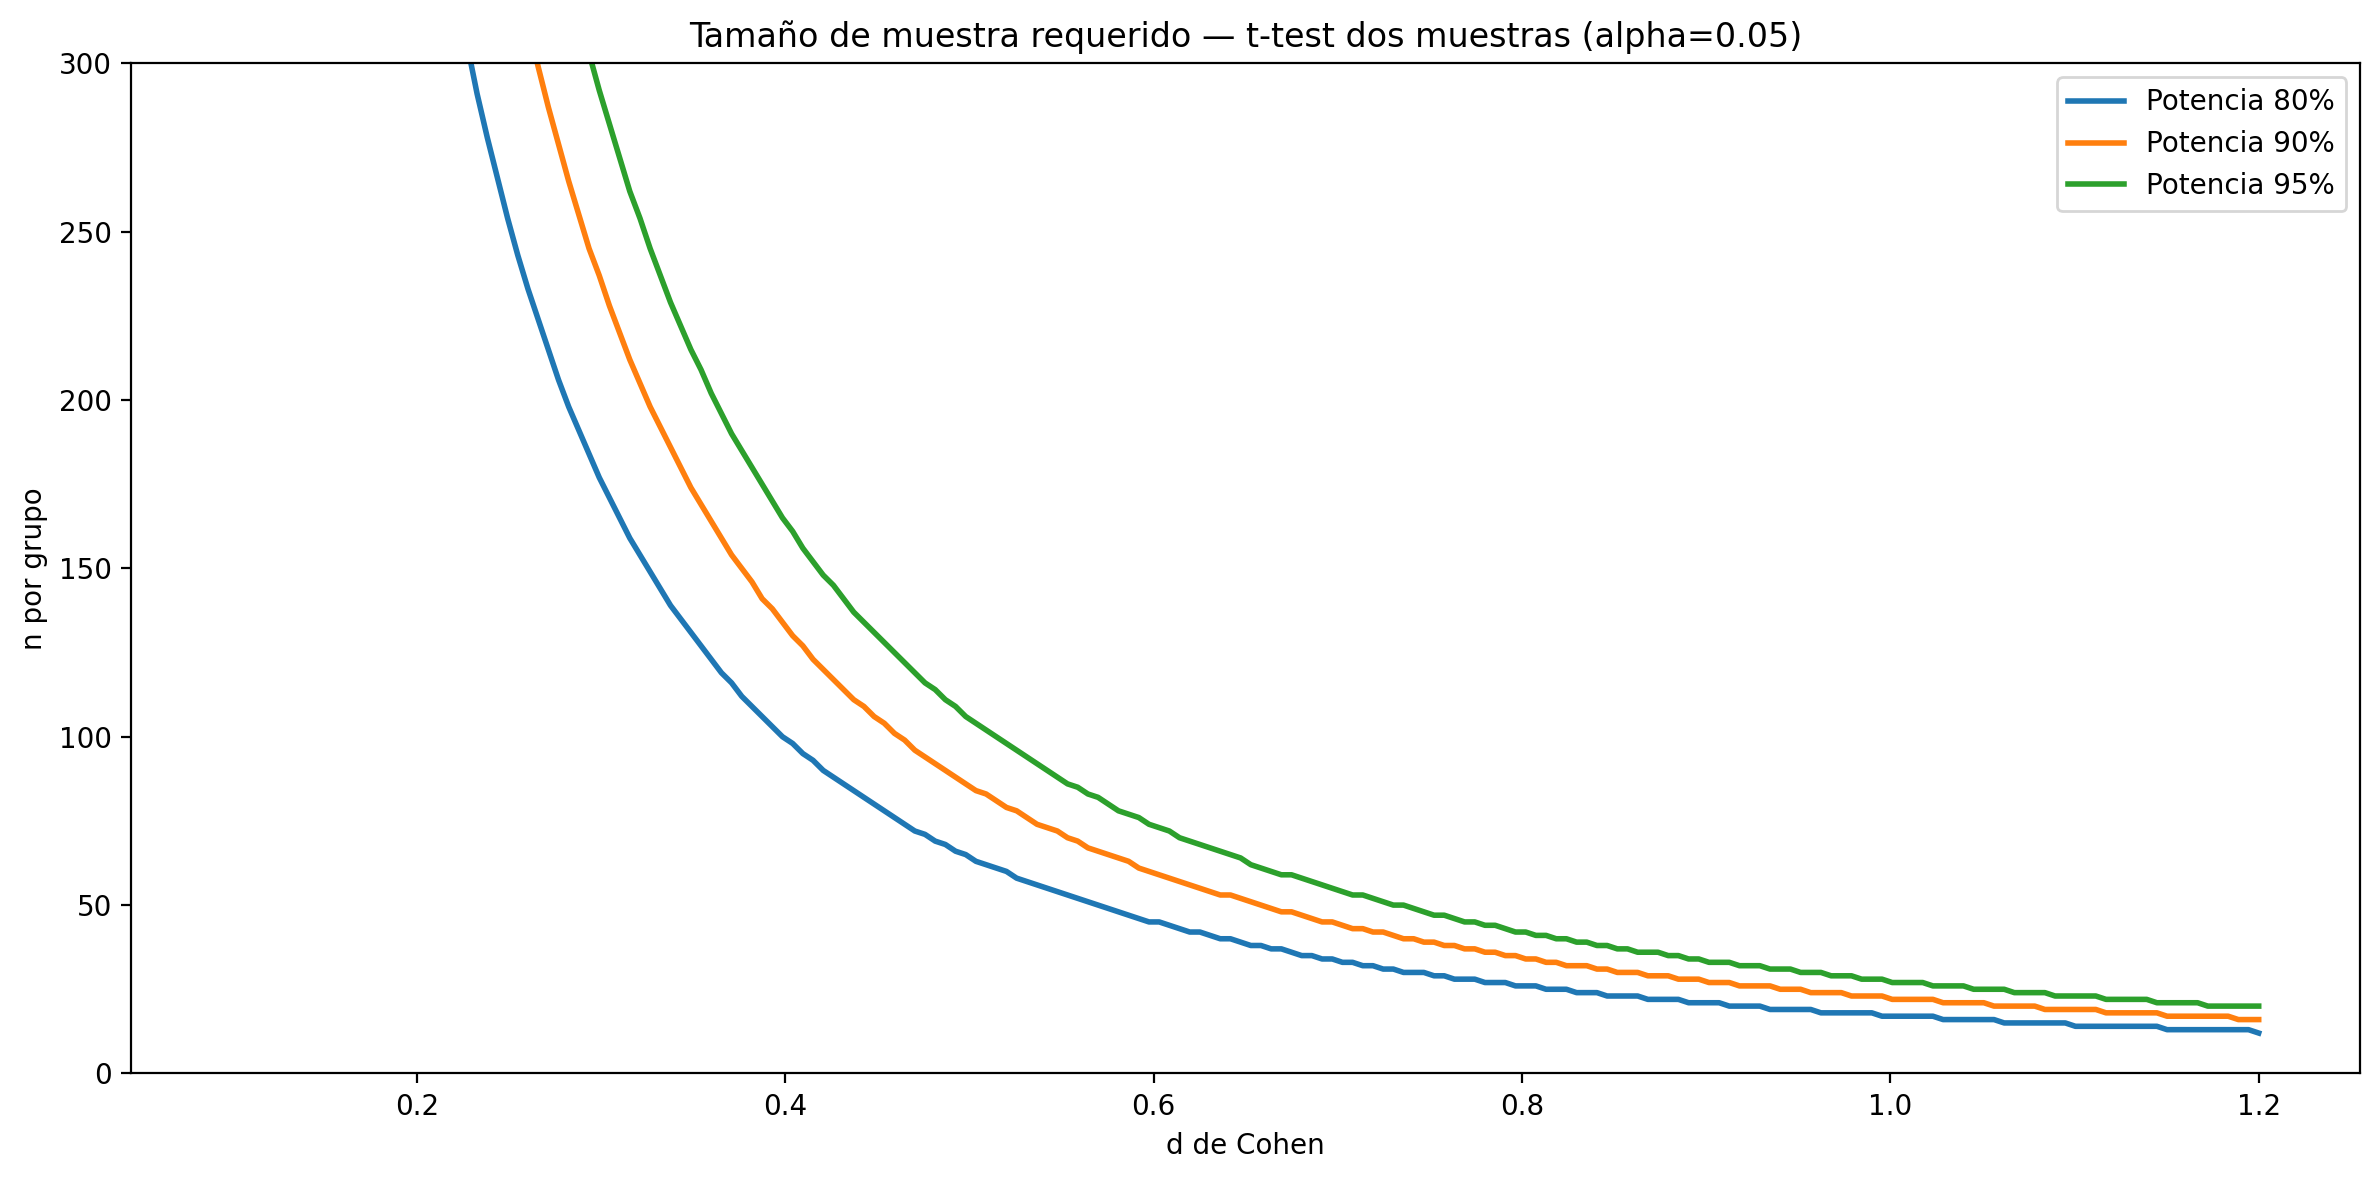

In [6]:
from statsmodels.stats.power import TTestIndPower

alpha = 0.05
analysis = TTestIndPower()

# Ejemplo puntual: d=0.5, n=25 por grupo
d = 0.5
power_ej = analysis.power(effect_size=d, nobs1=25, alpha=alpha, ratio=1.0, alternative='two-sided')
n_req = analysis.solve_power(effect_size=d, power=0.80, alpha=alpha, ratio=1.0, alternative='two-sided')
print(f'Potencia con d={d} y n=25 por grupo: {power_ej:.3f}')
print(f'n por grupo para potencia 80%: {int(np.ceil(n_req))}')

# Curvas OC: beta vs d para distintos n
d_grid = np.linspace(0.1, 1.2, 200)
n_vals = [10, 20, 40, 80]

fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
for n in n_vals:
    betas = [1 - analysis.power(effect_size=dv, nobs1=n, alpha=alpha, ratio=1.0, alternative='two-sided')
             for dv in d_grid]
    ax.plot(d_grid, betas, linewidth=2, label=f'n={n}')

ax.axhline(0.20, color='red', linestyle='--', linewidth=1.2, label='beta = 0.20')
ax.set_title(f'Curvas OC — t-test dos muestras (alpha={alpha})')
ax.set_xlabel('d de Cohen')
ax.set_ylabel('beta (error tipo II)')
ax.set_ylim(0, 1)
ax.legend()
plt.show()

# Tamaño de muestra requerido vs d
fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
for potencia in [0.80, 0.90, 0.95]:
    n_curve = [analysis.solve_power(effect_size=dv, power=potencia, alpha=alpha, ratio=1.0, alternative='two-sided')
               for dv in d_grid]
    n_curve = np.ceil(n_curve).astype(int)
    ax.plot(d_grid, n_curve, linewidth=2, label=f'Potencia {int(potencia*100)}%')

ax.set_title(f'Tamaño de muestra requerido — t-test dos muestras (alpha={alpha})')
ax.set_xlabel('d de Cohen')
ax.set_ylabel('n por grupo')
ax.set_ylim(0, 300)
ax.legend()
plt.tight_layout()
plt.show()

## Intervalos de confianza para la media con varianza desconocida

De forma similar, los intervalos de confianza se diferencian según el supuesto de varianza equivalente o no. De esta forma, los cálculos de los intervalos de confianza del $100(1-\alpha)\%$ son:

Cuando se supone que $\sigma_1 = \sigma_2 = \sigma$ entonces el intervalo de confianza para la diferencia de medias es:
$$
\overline{x}_1 - \overline{x}_2 - t_{\alpha/2, n_1 + n_2 - 2} s_p\sqrt{\frac{1}{n_1} + \frac{1}{n_2}} \le \mu_1 - \mu_2 \le \overline{x}_1 - \overline{x}_2 + t_{\alpha/2, n_1 + n_2 - 2} s_p\sqrt{\frac{1}{n_1} + \frac{1}{n_2}}
$$
Donde $s_p = \sqrt{[(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2]/(n_1+n_2 - 2)}$ 

En el caso donde  $\sigma_1 \neq \sigma_2$ se tiene que:
$$\overline{x}_1 - \overline{x}_2 - t_{\alpha/2, \nu} s_p\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}} \le \mu_1 - \mu_2 \le \overline{x}_1 - \overline{x}_2 + t_{\alpha/2, \nu} s_p\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}} $$

Donde $$\nu = \frac{\left( \frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1 - 1} + \frac{(s_2^2/n_2)^2}{n_2 - 1}}$$


In [7]:
# Ejemplo: IC para mu1 - mu2 con varianzas desconocidas
np.random.seed(7)
x1 = np.random.normal(loc=12, scale=2.0, size=28)
x2 = np.random.normal(loc=10.8, scale=2.8, size=24)

alpha = 0.05
n1, n2 = len(x1), len(x2)
xbar1, xbar2 = np.mean(x1), np.mean(x2)
s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
diff = xbar1 - xbar2

# Caso 1: varianzas iguales (pooled)
sp2 = ((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2)
se_pooled = np.sqrt(sp2 * (1/n1 + 1/n2))
t_crit_pool = stats.t.ppf(1 - alpha/2, df=n1 + n2 - 2)
ci_pool = (diff - t_crit_pool*se_pooled, diff + t_crit_pool*se_pooled)

# Caso 2: varianzas distintas (Welch)
se_welch = np.sqrt(s1/n1 + s2/n2)
nu = (s1/n1 + s2/n2)**2 / (((s1/n1)**2)/(n1 - 1) + ((s2/n2)**2)/(n2 - 1))
t_crit_welch = stats.t.ppf(1 - alpha/2, df=nu)
ci_welch = (diff - t_crit_welch*se_welch, diff + t_crit_welch*se_welch)

print('IC 95% para mu1 - mu2 (var desconocida):')
print(f'Pooled: [{ci_pool[0]:.3f}, {ci_pool[1]:.3f}]')
print(f'Welch: [{ci_welch[0]:.3f}, {ci_welch[1]:.3f}]')
print(f'gl Welch: {nu:.2f}')

IC 95% para mu1 - mu2 (var desconocida):
Pooled: [-0.585, 2.511]
Welch: [-0.660, 2.585]
gl Welch: 36.26


## Test no paramétrico: Mann-Whitney U

Cuando no es razonable suponer normalidad, una alternativa para dos muestras independientes es el test de Mann-Whitney U.

**Idea central**
En vez de comparar medias directamente, este test compara **rangos** entre ambas muestras. Si los datos de un grupo tienden a estar sistemáticamente por encima del otro, el estadístico U lo refleja.

**Hipótesis**
Una formulación general es:
$$
H_0: F_1(x) = F_2(x)\ \forall x, \qquad H_a: F_1(x) \neq F_2(x)
$$

Si ambas distribuciones tienen forma similar, la interpretación práctica se acerca a una prueba de diferencia de localización (por ejemplo, medianas).

**Supuestos prácticos**
1. Muestras independientes.
2. Variable al menos ordinal (idealmente continua).
3. Para interpretar como diferencia de ubicación, conviene que las distribuciones tengan formas comparables.

A continuación usamos dos distribuciones no normales con forma comparable (Gamma con mismo `shape`) y revisamos resultado, valor-p y tamaño de efecto.

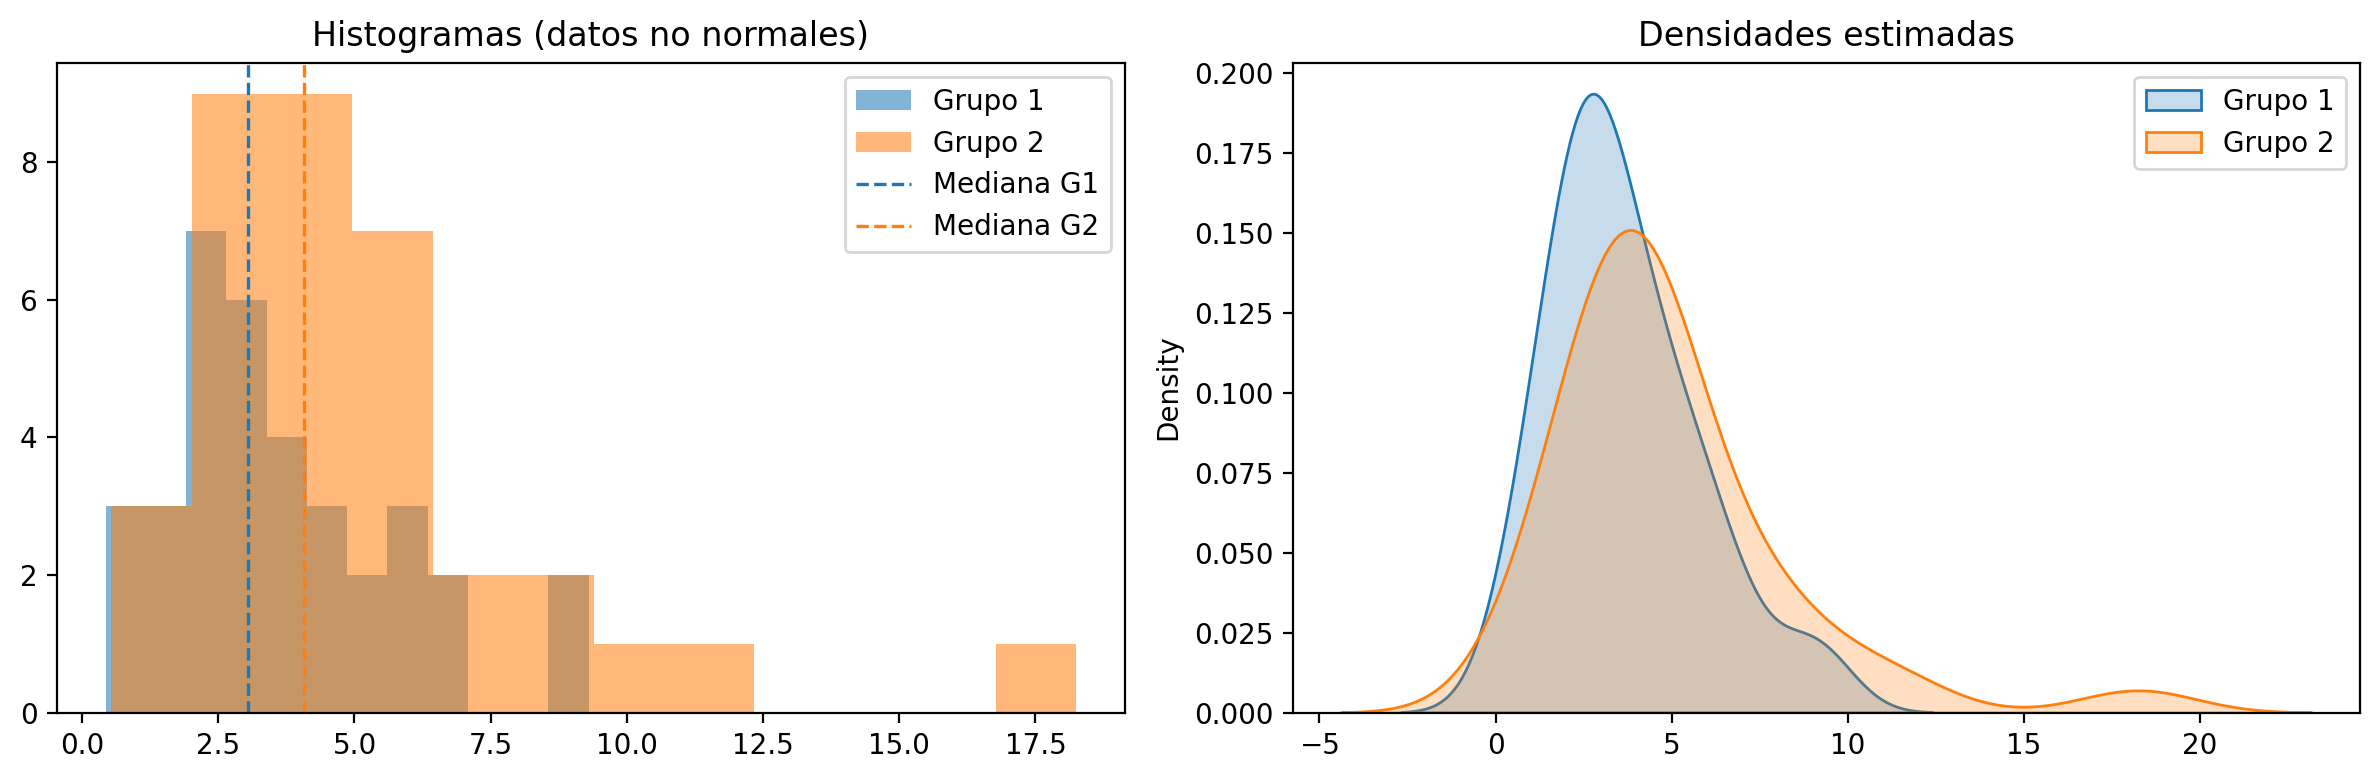

Mann-Whitney U (dos colas):
U = 458.000
p-value = 0.0705

Comparación con Welch t-test (referencia):
t = -1.910, p-value = 0.0611


In [8]:
np.random.seed(42)
datos1 = np.random.gamma(shape=2.0, scale=2.0, size=35)  # no normal, grupo 1
datos2 = np.random.gamma(shape=2.0, scale=2.5, size=35)  # no normal, grupo 2 (misma forma, distinto desplazamiento/escala)

# Diagnóstico visual
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=200)
ax[0].hist(datos1, bins=12, alpha=0.55, label='Grupo 1')
ax[0].hist(datos2, bins=12, alpha=0.55, label='Grupo 2')
ax[0].axvline(np.median(datos1), color='C0', linestyle='--', linewidth=1.2, label='Mediana G1')
ax[0].axvline(np.median(datos2), color='C1', linestyle='--', linewidth=1.2, label='Mediana G2')
ax[0].set_title('Histogramas (datos no normales)')
ax[0].legend()

sns.kdeplot(datos1, fill=True, alpha=0.25, label='Grupo 1', ax=ax[1])
sns.kdeplot(datos2, fill=True, alpha=0.25, label='Grupo 2', ax=ax[1])
ax[1].set_title('Densidades estimadas')
ax[1].legend()
plt.tight_layout()
plt.show()

# Mann-Whitney U
u_statistic, p_value = stats.mannwhitneyu(datos1, datos2, alternative='two-sided')

print('Mann-Whitney U (dos colas):')
print(f'U = {u_statistic:.3f}')
print(f'p-value = {p_value:.4f}')

# Comparación de referencia (paramétrica)
t_welch, p_welch = stats.ttest_ind(datos1, datos2, equal_var=False)
print('\nComparación con Welch t-test (referencia):')
print(f't = {t_welch:.3f}, p-value = {p_welch:.4f}')

## Test de igualdad de varianzas (Levene y F-test)

Antes de decidir entre t-test con varianzas iguales o Welch, podemos evaluar homogeneidad de varianzas.

- **Levene** es más robusto frente a desviaciones de normalidad.
- **F-test** clásico es sensible a no normalidad, por lo que conviene usarlo con cautela.

En ambos casos, la hipótesis nula es $H_0: \sigma_1^2 = \sigma_2^2$.

In [9]:
np.random.seed(1234)
var_g1 = np.random.normal(loc=10, scale=2.0, size=30)
var_g2 = np.random.normal(loc=10, scale=3.0, size=30)

# Levene (recomendado en práctica)
lev_stat, lev_p = stats.levene(var_g1, var_g2)
print('Levene test:')
print(f'  estadístico = {lev_stat:.3f}, p-value = {lev_p:.4f}')

# F-test clásico (sensible a no normalidad)
n1, n2 = len(var_g1), len(var_g2)
s1 = np.var(var_g1, ddof=1)
s2 = np.var(var_g2, ddof=1)

if s1 >= s2:
    f_stat = s1 / s2
    dfn, dfd = n1 - 1, n2 - 1
else:
    f_stat = s2 / s1
    dfn, dfd = n2 - 1, n1 - 1

p_right = stats.f.sf(f_stat, dfn=dfn, dfd=dfd)
p_f = 2 * min(p_right, 1 - p_right)

print('\nF-test (dos colas):')
print(f'  F = {f_stat:.3f}, p-value = {p_f:.4f}')

Levene test:
  estadístico = 0.487, p-value = 0.4881

F-test (dos colas):
  F = 1.720, p-value = 0.1500


## Tests para muestras pareadas

Cuando las observaciones vienen en pares (antes/después, mediciones repetidas), no corresponde usar tests para muestras independientes. En esta alternativa, se utilizan los test pareados. Los test pareados presentan el siguiente estadístico de prueba:

$T_0 = \frac{\overline{D}-\Delta_0}{S_D/\sqrt{n}}; T_0 \sim t_{n-1}$

Donde $\overline{D} = \overline{X}_1 - \overline{X}_2$ y $S_D = var( \overline{X}_1 - \overline{X}_2)$. En esta caso, debido a que las muestras vienen en pares, se asume que $n$ es constante. 

Así, los valores-p se calculan comparando con una distribución $t$.

- $H_a: \mu_1 - \mu_2 \neq \Delta_0$ (dos colas): $p$-valor $= 2\,[1 - F_{t, df}(|t_0|)]$
- $H_a: \mu_1 - \mu_2 > \Delta_0$ (cola derecha): $p$-valor $= 1 - F_{t,df}(t_0)$
- $H_a: \mu_1 - \mu_2 < \Delta_0$ (cola izquierda): $p$-valor $= F_{t,df}(t_0)$

Donde $df = n-1$.

Complementariamente, cuando se trabaja con muestras pareadas que no siguen una distribución normal, la prueba no-paramétrica a usar es la prueba de Wilcoxon Singed-Rank (si, la misma que para una muestra). 



Test pareados:
t pareado-> t=3.229, p-value=0.0031
Wilcoxon par-> W=79.000, p-value=0.0010
Media diferencia (despues-antes) = -1.840


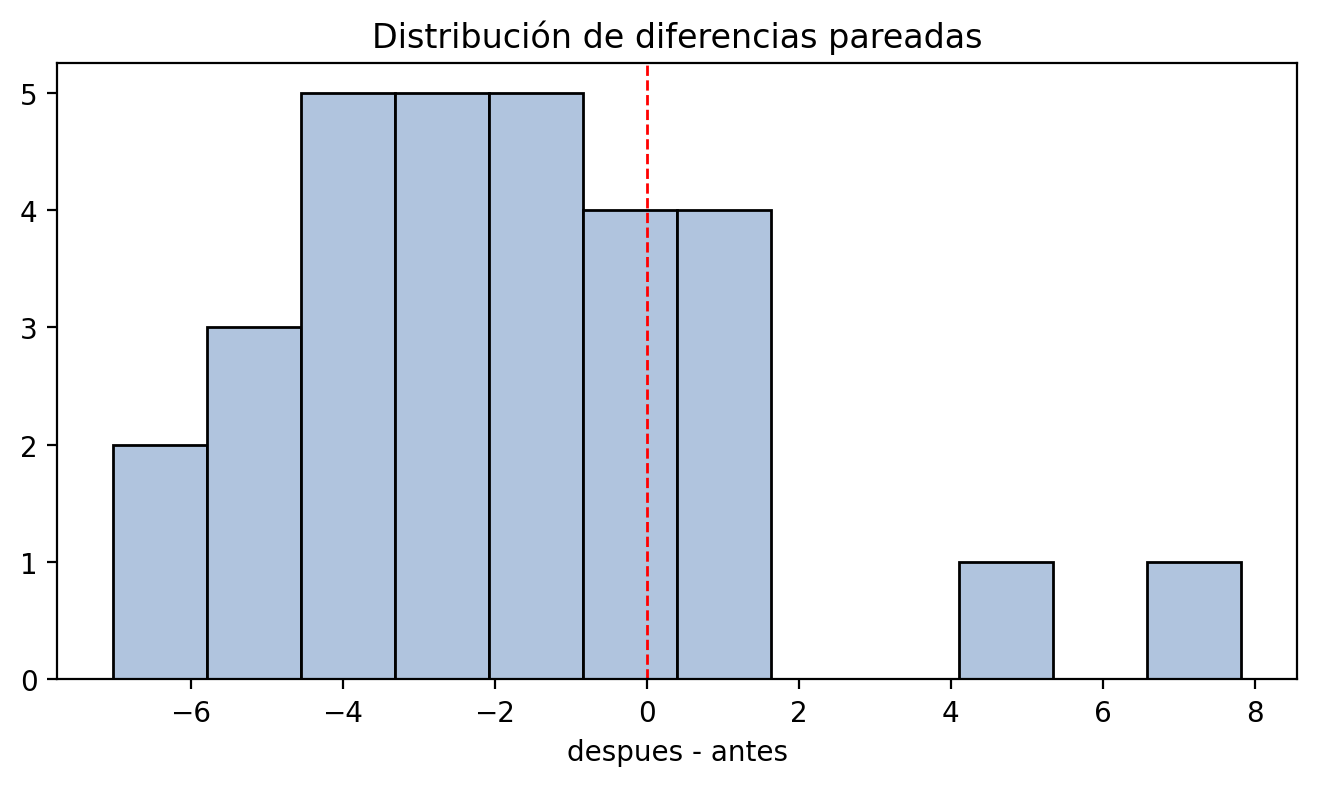

In [10]:
np.random.seed(2026)
n = 30
antes = np.random.normal(loc=75, scale=8, size=n)
despues = antes - np.random.normal(loc=2.0, scale=3.0, size=n)

# t-test pareado
t_rel, p_rel = stats.ttest_rel(antes, despues, alternative='two-sided')

# Wilcoxon pareado
w_stat, p_w = stats.wilcoxon(antes, despues, alternative='two-sided')

diff_pares = despues - antes
print('Test pareados:')
print(f't pareado-> t={t_rel:.3f}, p-value={p_rel:.4f}')
print(f'Wilcoxon par-> W={w_stat:.3f}, p-value={p_w:.4f}')
print(f'Media diferencia (despues-antes) = {np.mean(diff_pares):.3f}')

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
ax.hist(diff_pares, bins=12, color='lightsteelblue', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Distribución de diferencias pareadas')
ax.set_xlabel('despues - antes')
plt.show()

## Test de hipotesis para dos proporciones

Cuando se comparan las tasas de exito de dos grupos independientes:

$$H_0: p_1 = p_2 \qquad H_a: p_1 \neq p_2$$

**Estadistico de prueba** (aproximacion normal):

$$z_0 = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})\left(\dfrac{1}{n_1}+\dfrac{1}{n_2}\right)}}, \quad
  \hat{p} = \frac{x_1+x_2}{n_1+n_2}$$

**IC al $(1-\alpha)$ para $p_1 - p_2$:**

$$(\hat{p}_1-\hat{p}_2) \pm z_{\alpha/2}\sqrt{\frac{\hat{p}_1(1-\hat{p}_1)}{n_1}+\frac{\hat{p}_2(1-\hat{p}_2)}{n_2}}$$

`statsmodels.stats.proportion.proportions_ztest` implementa este test
directamente dado los conteos y los tamanos de muestra.

In [11]:
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats_prop

np.random.seed(42)
grupo_1 = np.random.binomial(1, p=0.30, size=60)
grupo_2 = np.random.binomial(1, p=0.50, size=60)

count = np.array([grupo_1.sum(), grupo_2.sum()])
nobs  = np.array([len(grupo_1), len(grupo_2)])

# H0: p1 = p2, Ha: p1 != p2
z_stat, p_val = proportions_ztest(count, nobs, alternative='two-sided')
print(f'z = {z_stat:.4f},  p-value = {p_val:.4f}')

# IC 95% para p1 - p2
p1, p2 = count / nobs
z_crit = stats_prop.norm.ppf(0.975)
se = np.sqrt(p1*(1-p1)/nobs[0] + p2*(1-p2)/nobs[1])
print(f'IC 95% para p1-p2: ({p1-p2 - z_crit*se:.4f}, {p1-p2 + z_crit*se:.4f})')

z = -2.6286,  p-value = 0.0086
IC 95% para p1-p2: (-0.4022, -0.0644)


## Analisis de Varianza (ANOVA) de un factor

Cuando se quiere comparar las medias de **tres o mas grupos** simultaneamente, los tests de dos muestras ya no son suficientes (comparar todos los pares infla el error tipo I). El **ANOVA de un factor** resuelve esto con una sola prueba.

**Hipotesis**

$$H_0: \mu_1 = \mu_2 = \cdots = \mu_k \qquad H_a: \text{al menos dos medias difieren}$$

**Supuestos**
1. Las observaciones son independientes.
2. Cada grupo sigue una distribucion Normal.
3. Las varianzas de los grupos son iguales (homocedasticidad).

**Descomposicion de la varianza total**

$$SS_T = SS_{\text{Tratamientos}} + SS_E$$

| Fuente | SS | gl | MS | F |
|--------|----|----|----|-|
| Tratamientos | $SS_A = \sum_i n_i(\bar{Y}_{i\cdot} - \bar{Y}_{\cdot\cdot})^2$ | $k-1$ | $MS_A = SS_A/(k-1)$ | $F_0 = MS_A/MS_E$ |
| Error | $SS_E = \sum_i\sum_j (y_{ij}-\bar{Y}_{i\cdot})^2$ | $N-k$ | $MS_E = SS_E/(N-k)$ | |
| Total | $SS_T$ | $N-1$ | | |

Bajo $H_0$, $F_0 \sim F_{k-1,\, N-k}$. Se rechaza $H_0$ cuando $F_0 > f_{\alpha, k-1, N-k}$.

> **Nota:** el ANOVA solo indica que *al menos un par* de medias difiere. Para identificar cuales, se usan comparaciones multiples (Tukey HSD, Bonferroni).

**Comprobacion de supuestos**
- Normalidad de residuos: QQ-plot de $e_{ij} = y_{ij} - \bar{Y}_{i\cdot}$.
- Homocedasticidad: Levene's test o grafico de residuos vs. valores ajustados.

In [12]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

np.random.seed(2026)

# Tres grupos con medias distintas, misma varianza
grupo_A = np.random.normal(loc=10.0, scale=2.0, size=20)
grupo_B = np.random.normal(loc=12.0, scale=2.0, size=20)
grupo_C = np.random.normal(loc=11.5, scale=2.0, size=20)

# ANOVA de un factor via scipy
f_stat, p_val = stats.f_oneway(grupo_A, grupo_B, grupo_C)
print(f'ANOVA F = {f_stat:.3f},  p-value = {p_val:.4f}')

alpha = 0.05
f_crit = stats.f.ppf(1 - alpha, dfn=2, dfd=3*20 - 3)

# Tabla ANOVA manual
grupos = [grupo_A, grupo_B, grupo_C]
k = len(grupos)
N = sum(len(g) for g in grupos)
grand_mean = np.concatenate(grupos).mean()

SS_A = sum(len(g) * (g.mean() - grand_mean)**2 for g in grupos)
SS_E = sum(((g - g.mean())**2).sum() for g in grupos)
SS_T = SS_A + SS_E

MS_A = SS_A / (k - 1)
MS_E = SS_E / (N - k)

tabla = pd.DataFrame({
    'Fuente': ['Tratamientos', 'Error', 'Total'],
    'SS': [SS_A, SS_E, SS_T],
    'gl': [k-1, N-k, N-1],
    'MS': [MS_A, MS_E, None],
    'F': [MS_A / MS_E, None, None]
})
print('\nTabla ANOVA:')
print(tabla.to_string(index=False))

ANOVA F = 4.706,  p-value = 0.0128

Tabla ANOVA:
      Fuente         SS  gl        MS        F
Tratamientos  48.941380   2 24.470690 4.705903
       Error 296.399948  57  5.199999      NaN
       Total 345.341328  59       NaN      NaN


### Verificacion de normalidad por grupo

Antes de ajustar ANOVA conviene confirmar que los datos en cada grupo siguen
una distribucion aproximadamente normal. Se usan QQ-plots y el test de
Shapiro-Wilk. (La homocedasticidad se verifica con Levene, mostrado mas
adelante junto con los diagnosticos de residuos.)

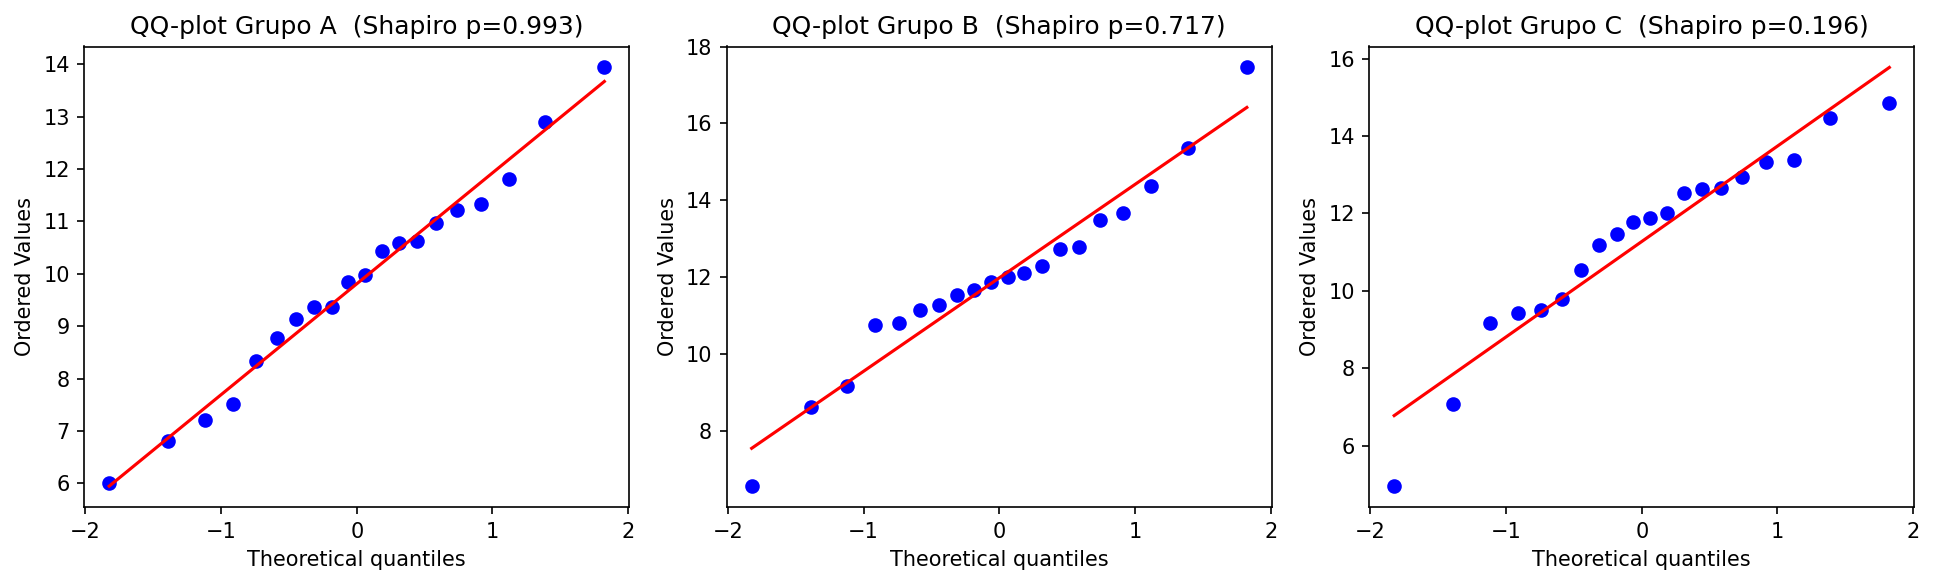

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=150)
for ax, (nombre, grupo) in zip(axes, [('A', grupo_A), ('B', grupo_B), ('C', grupo_C)]):
    stats.probplot(grupo, dist='norm', plot=ax)
    sw_p = stats.shapiro(grupo).pvalue
    ax.set_title(f'QQ-plot Grupo {nombre}  (Shapiro p={sw_p:.3f})')
plt.tight_layout()
plt.show()

Tukey HSD (p-values ajustados):
  A vs B: p = 0.0108
  A vs C: p = 0.1136
  B vs C: p = 0.5965


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_38338/1906295223.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([grupo_A, grupo_B, grupo_C], labels=['A', 'B', 'C'])


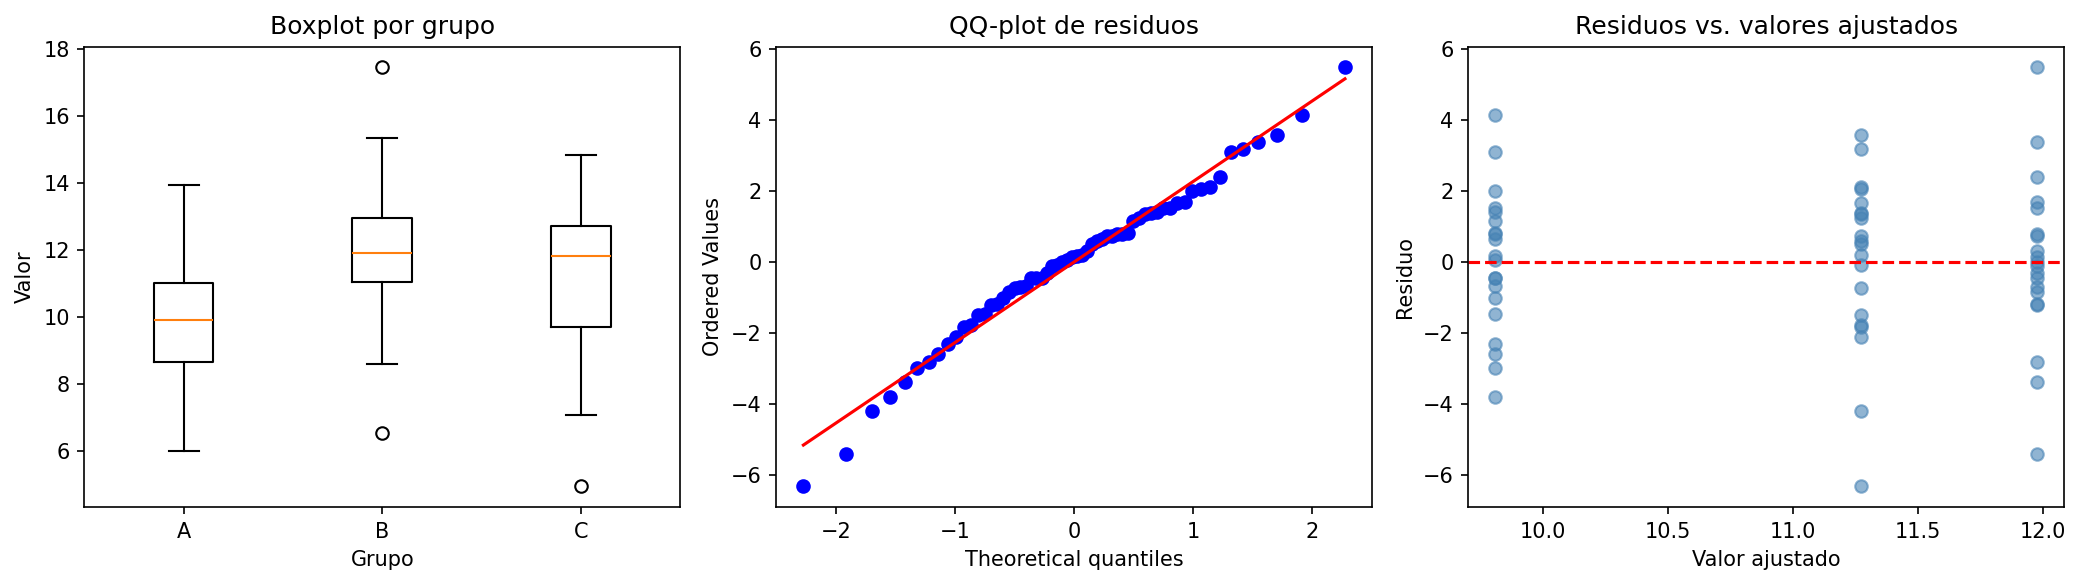


Levene test: W = 0.100, p = 0.9054


In [14]:
from scipy.stats import tukey_hsd

# Post-hoc Tukey HSD (identifica cuales pares difieren)
result = tukey_hsd(grupo_A, grupo_B, grupo_C)
nombres = ['A', 'B', 'C']
print('Tukey HSD (p-values ajustados):')
for i in range(len(nombres)):
    for j in range(i+1, len(nombres)):
        pv = result.pvalue[i, j]
        print(f'  {nombres[i]} vs {nombres[j]}: p = {pv:.4f}')

# Diagnostico de supuestos
fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=150)

# Panel 1: boxplot por grupo
data_long = pd.DataFrame({
    'valor': np.concatenate(grupos),
    'grupo': ['A']*20 + ['B']*20 + ['C']*20
})
axes[0].boxplot([grupo_A, grupo_B, grupo_C], labels=['A', 'B', 'C'])
axes[0].set_title('Boxplot por grupo')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('Valor')

# Panel 2: QQ-plot de residuos
residuos = np.concatenate([g - g.mean() for g in grupos])
stats.probplot(residuos, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot de residuos')

# Panel 3: residuos vs valores ajustados
valores_ajustados = np.concatenate([np.full(len(g), g.mean()) for g in grupos])
axes[2].scatter(valores_ajustados, residuos, alpha=0.6, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuos vs. valores ajustados')
axes[2].set_xlabel('Valor ajustado')
axes[2].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

# Levene: verificar homocedasticidad
lev_stat, lev_p = stats.levene(*grupos)
print(f'\nLevene test: W = {lev_stat:.3f}, p = {lev_p:.4f}')

### Introduccion a statsmodels

`statsmodels` utiliza notacion de formulas similar a R:
- `'valor ~ C(grupo)'` -- `valor` es la variable respuesta; `grupo` es un factor categorico.
- `ols(formula, data)` -- ajusta un modelo lineal ordinario.
- `anova_lm(modelo)` -- genera la tabla ANOVA a partir del modelo ajustado.

El dataframe debe tener una columna numerica de respuesta y una columna de grupo
(string o categorica). Las demas secciones de este capitulo usan exactamente este flujo.

In [15]:
import statsmodels.formula.api as smf
import statsmodels.stats.anova as sma

modelo_sm = smf.ols('valor ~ C(grupo)', data=data_long).fit()
tabla_sm  = sma.anova_lm(modelo_sm, typ=1)
print(tabla_sm)

            df      sum_sq    mean_sq         F    PR(>F)
C(grupo)   2.0   48.941380  24.470690  4.705903  0.012836
Residual  57.0  296.399948   5.199999       NaN       NaN


### Alternativa mas pythonica: `pingouin`

`pingouin` ofrece la misma prueba con una interfaz mas directa:
- Sin notacion de formulas: se pasan los nombres de columna como strings.
- Retorna un `DataFrame` de pandas listo para inspeccionar o exportar.
- Incluye tamano del efecto (`np2`) y potencia en la misma tabla.

In [16]:
import pingouin as pg

aov = pg.anova(data=data_long, dv='valor', between='grupo', detailed=True)
display(aov)

posthoc = pg.pairwise_tukey(data=data_long, dv='valor', between='grupo')
display(posthoc)

,Source,SS,DF,MS,F,p_unc,np2
0,grupo,48.941380,2,24.470690,4.705903,0.012836,0.141719
1,Within,296.399948,57,5.199999,NaN,NaN,NaN


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,A,B,9.809044,11.976903,-2.167859,0.72111,-3.006280,0.010802,-0.964553
1,A,C,9.809044,11.274933,-1.465889,0.72111,-2.032823,0.113602,-0.643224
2,B,C,11.976903,11.274933,0.701970,0.72111,0.973457,0.596493,0.286727


### Correccion de Bonferroni como alternativa a Tukey

`pg.pairwise_tests` con `padjust='bonf'` aplica la correccion de Bonferroni
a los p-values de las comparaciones por pares. Es mas conservadora que Tukey
pero aplicable a cualquier conjunto de hipotesis (no solo pares balanceados).

In [19]:
bonf = pg.pairwise_tests(data=data_long, dv='valor', between='grupo',
                         padjust='bonf', alpha=0.05)
display(bonf)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,grupo,A,B,False,True,-3.112013,38.0,two-sided,0.003520,0.01056,bonf,11.245,-0.964553
1,grupo,A,C,False,True,-2.075285,38.0,two-sided,0.044780,0.13434,bonf,1.631,-0.643224
2,grupo,B,C,False,True,0.925091,38.0,two-sided,0.360757,1.00000,bonf,0.434,0.286727


## Alternativa no parametrica a ANOVA: Kruskal-Wallis

Cuando los supuestos de normalidad o homocedasticidad no se cumplen, el test de **Kruskal-Wallis** es la alternativa no parametrica al ANOVA de un factor.

- Hipotesis: $H_0$: todas las distribuciones son identicas (igual localizacion).
- Basa el estadistico en los **rangos** de las observaciones en vez de los valores originales.
- El estadistico $H$ sigue aproximadamente $\chi^2_{k-1}$ para $n$ suficientemente grande.

Post-hoc para Kruskal-Wallis: comparaciones por pares con Mann-Whitney U y correccion de Bonferroni.

In [ ]:
# Kruskal-Wallis (no parametrico)
h_stat, p_kw = stats.kruskal(grupo_A, grupo_B, grupo_C)
print(f'Kruskal-Wallis H = {h_stat:.3f},  p-value = {p_kw:.4f}')

# Post-hoc: Mann-Whitney con correccion Bonferroni
pares = [('A', grupo_A, 'B', grupo_B),
         ('A', grupo_A, 'C', grupo_C),
         ('B', grupo_B, 'C', grupo_C)]
n_comparaciones = len(pares)

print('\nPost-hoc Mann-Whitney (Bonferroni):')
for (n1, g1, n2, g2) in pares:
    u_stat, p_raw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    p_bonf = min(p_raw * n_comparaciones, 1.0) 
    print(f'  {n1} vs {n2}: U = {u_stat:.1f},  p (Bonferroni) = {p_bonf:.4f}')

Kruskal-Wallis H = 9.848,  p-value = 0.0073

Post-hoc Mann-Whitney (Bonferroni):
  A vs B: U = 88.0,  p (Bonferroni) = 0.0077
  A vs C: U = 116.0,  p (Bonferroni) = 0.0717
  B vs C: U = 221.0,  p (Bonferroni) = 1.0000
